In [3]:
pip install tensorflow numpy matplotlib opencv-python scikit-learn Pillow


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Import standard libraries, others will be iported at point of need

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
    # for filename in filenames:
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:


images = []
labels = []

# Loop through each subfolder in the dataset directory.
for subfolder in os.listdir('D:\college\Blood_group\Augmented Dataset'):
    # Construct the full path to the subfolder.
       
    subfolder_path = os.path.join('D:\college\Blood_group\Augmented Dataset', subfolder)
    # Loop through each category folder.
    for folder in os.listdir(subfolder_path):
        # Construct the full path to the category folder.
        subfolder_path2 = os.path.join(subfolder_path, folder)
        # Loop through each image file in the category folder.
        for image_filename in os.listdir(subfolder_path2):
            # Construct the full path to the image file.
            image_path = os.path.join(subfolder_path2, image_filename)
            # Append the image path to the images list.
            images.append(image_path)
            # Append the folder name (class label) to the labels list.
            labels.append(folder)
            
# Create a Pandas DataFrame with two columns: 'image' (file path) and 'label' (class label).
df = pd.DataFrame({'image': images, 'label': labels})
# Display the DataFrame to check this has worked correctly.
df

,image,label
0,D:\college\Blood_group\Augmented Dataset\Augme...,Central Serous Chorioretinopathy-Color Fundus
1,D:\college\Blood_group\Augmented Dataset\Augme...,Central Serous Chorioretinopathy-Color Fundus
2,D:\college\Blood_group\Augmented Dataset\Augme...,Central Serous Chorioretinopathy-Color Fundus
3,D:\college\Blood_group\Augmented Dataset\Augme...,Central Serous Chorioretinopathy-Color Fundus
4,D:\college\Blood_group\Augmented Dataset\Augme...,Central Serous Chorioretinopathy-Color Fundus
...,...,...
16237,D:\college\Blood_group\Augmented Dataset\Augme...,Retinitis Pigmentosa
16238,D:\college\Blood_group\Augmented Dataset\Augme...,Retinitis Pigmentosa
16239,D:\college\Blood_group\Augmented Dataset\Augme...,Retinitis Pigmentosa
16240,D:\college\Blood_group\Augmented Dataset\Augme...,Retinitis Pigmentosa


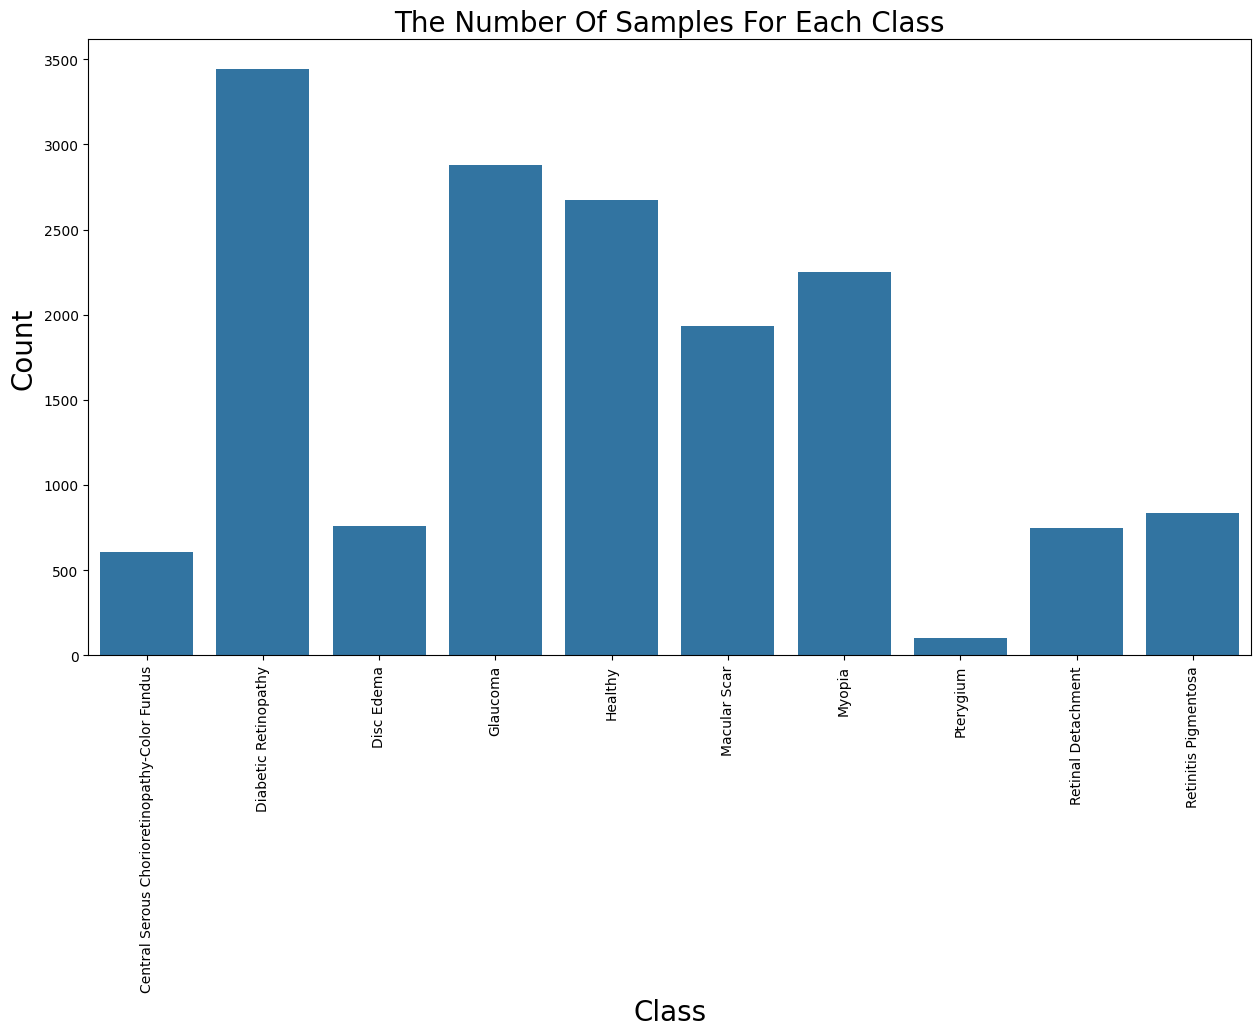

In [7]:


plt.figure(figsize=(15, 8))

ax = sns.countplot(x=df.label)
ax.set_xlabel("Class", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
plt.title('The Number Of Samples For Each Class', fontsize=20)
plt.xticks(rotation=90)
plt.show()

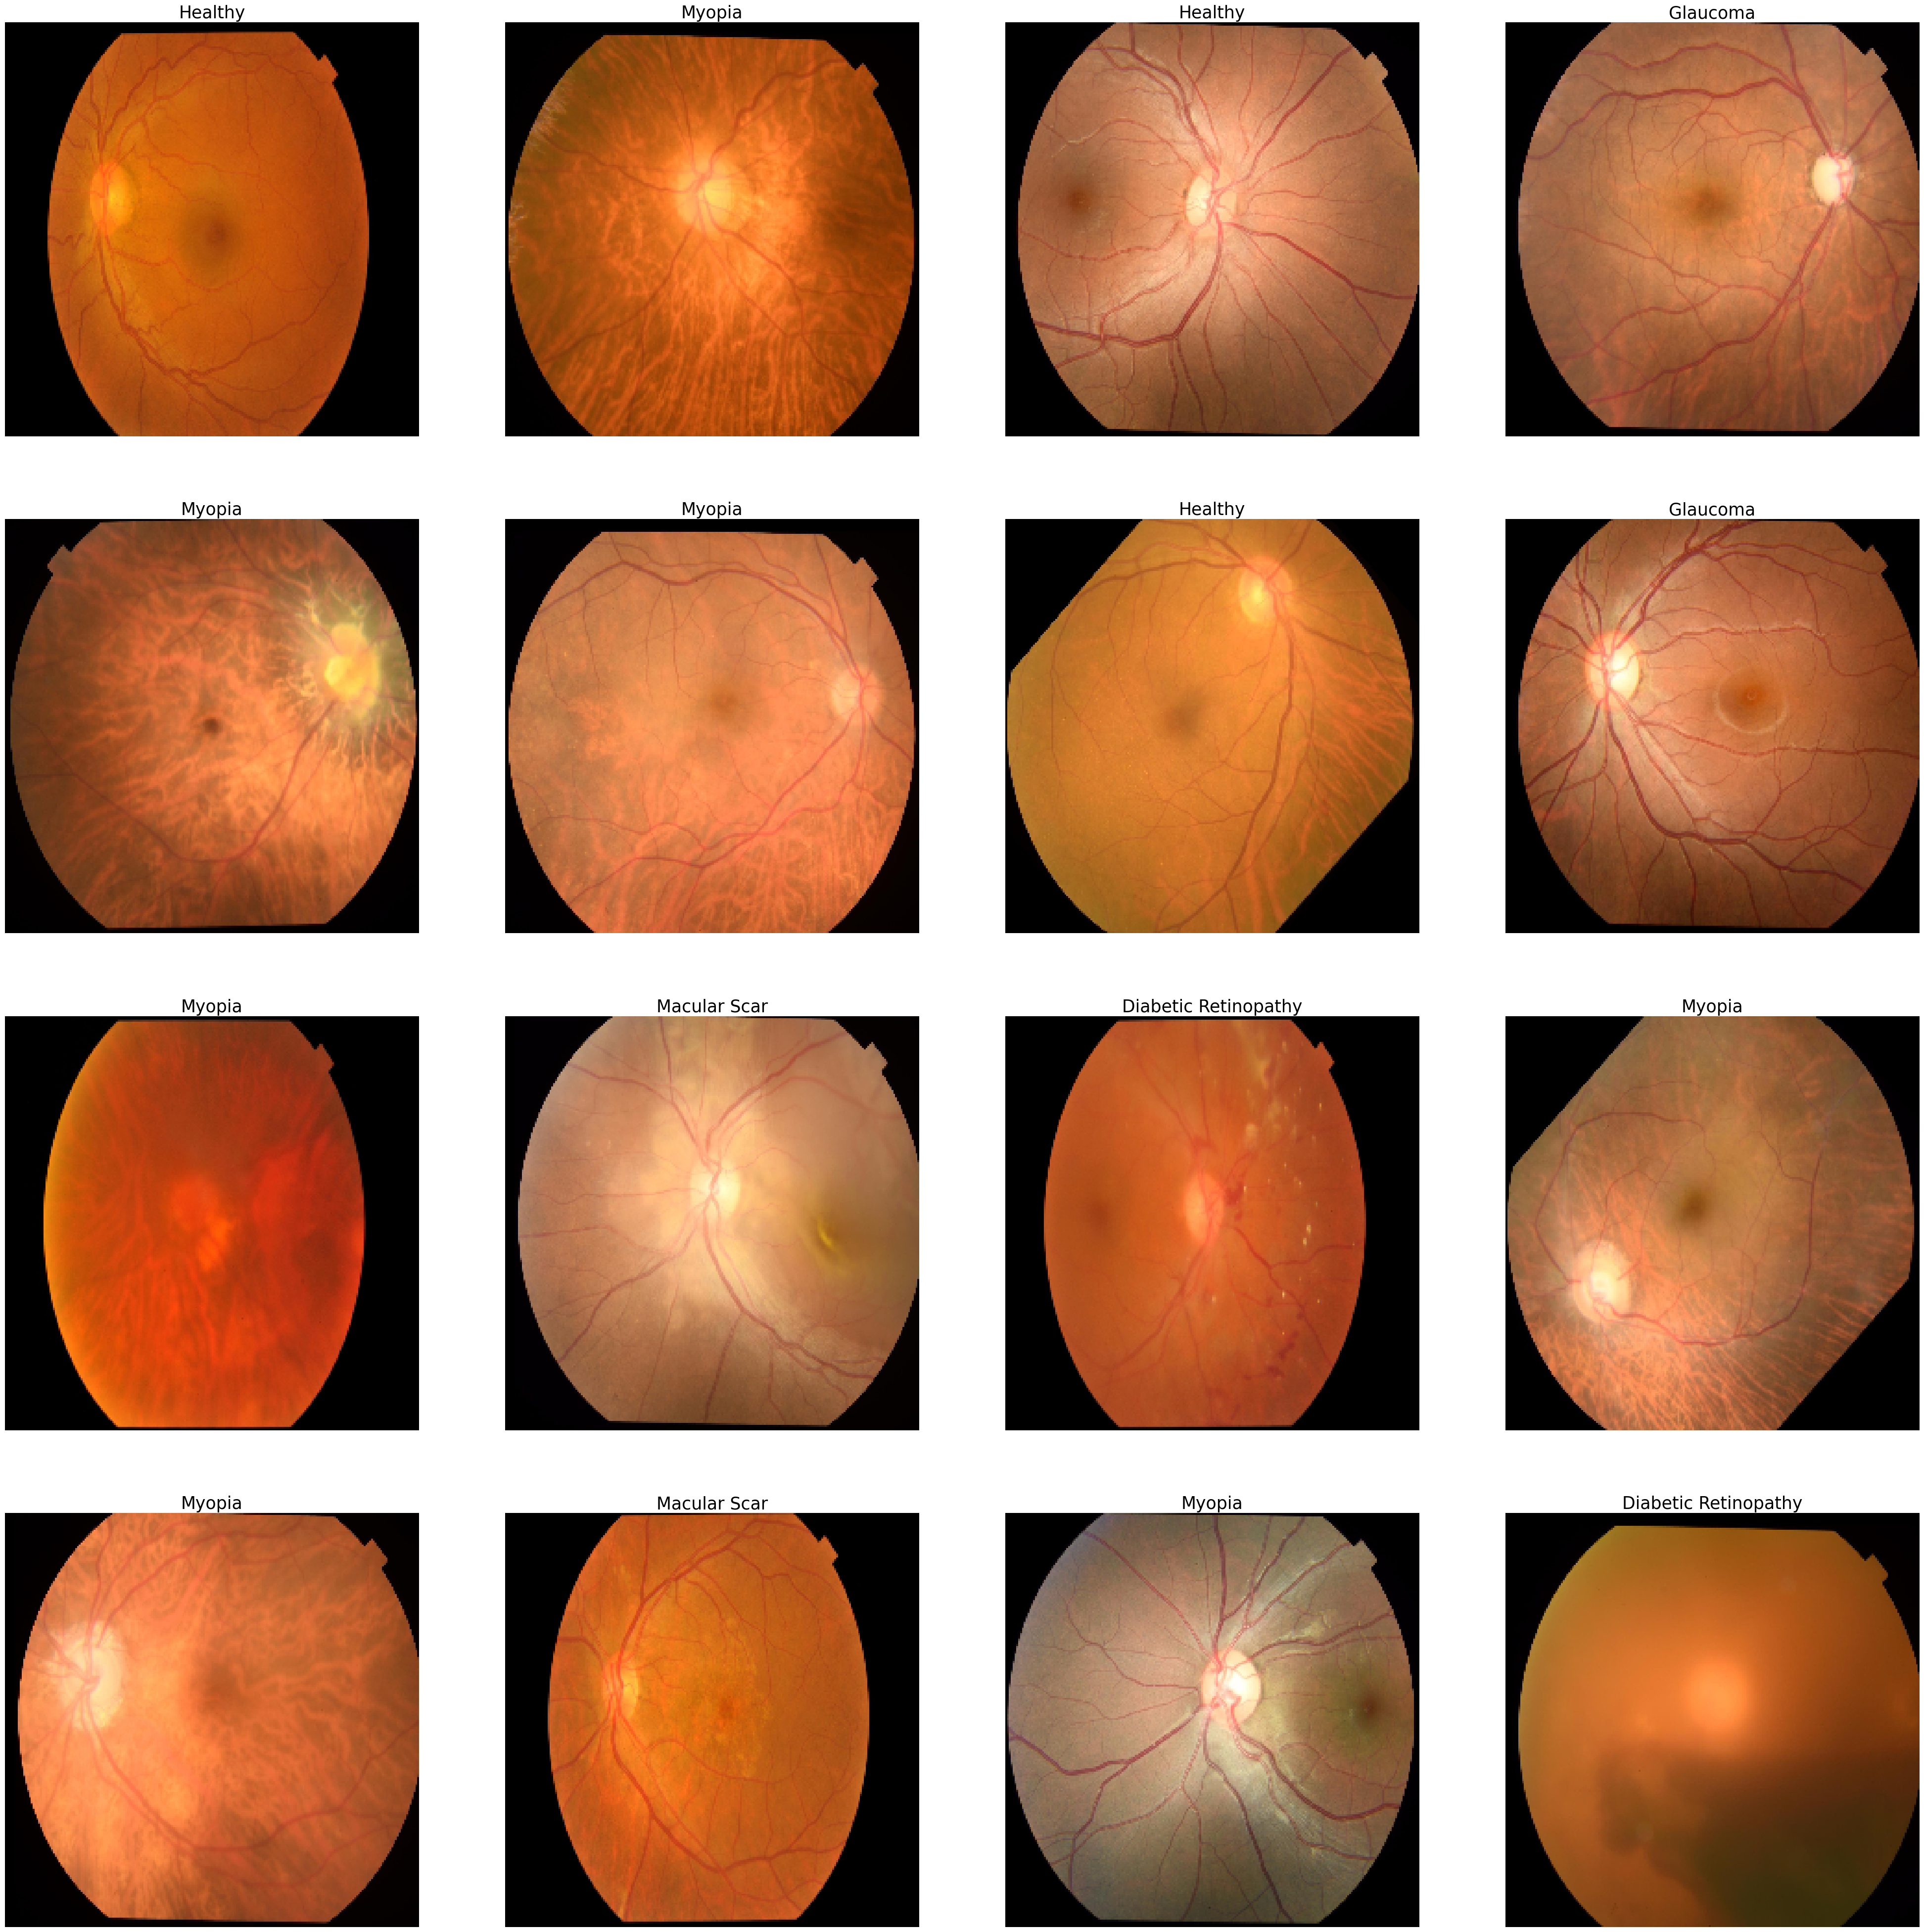

In [8]:
import cv2
# Create a figure with a large size for displaying the images in a grid
plt.figure(figsize=(50,50))

for n, i in enumerate(np.random.randint(0, len(df), 16)):
    plt.subplot(4, 4, n+1)
    img = cv2.imread(df.image[i])
    # Resize the image to 224x224 pixels (standard input size for many models)
    img = cv2.resize(img, (224, 224))
    # Convert the image from BGR (OpenCV format) to RGB (for correct display with matplotlib)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.title(df.label[i], fontsize=25)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test1, y_train, y_test1 = train_test_split(
    df['image'],  # Features (images)
    df['label'],  # Labels (categories)
    test_size=0.2, 
    random_state=101,  # Fixing the random state for reproducibility, with a nod to Orwell
    shuffle=True,  # Shuffle the dataset before splitting
    stratify=df['label']  # Ensure the label distribution is the same in both train and test sets
)
# Further split the initial test set (X_test1) into validation and final test sets, both of equal size
X_val, X_test, y_val, y_test = train_test_split(
    X_test1,  # Features (images) from the initial test set
    y_test1,  # Labels (categories) from the initial test set
    test_size=0.5,  # 10% of the initial dataset will be used for the final test set
    random_state=101,  # Fixing the random state for reproducibility, with a nod to Orwell
    shuffle=True,  # Shuffle the data before splitting
    stratify=y_test1  # Ensure the label distribution is the same in both validation and test sets
)
# Create a DataFrame for the training set with images and corresponding labels
df_train = pd.DataFrame({'image': X_train, 'label': y_train})
# Create a DataFrame for the final test set with images and corresponding labels
df_test = pd.DataFrame({'image': X_test, 'label': y_test})
# Create a DataFrame for the validation set with images and corresponding labels
df_val = pd.DataFrame({'image': X_val, 'label': y_val})

# Tensorflow Model Definition

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the target image size and batch size for data processing
image_size = (224, 224)  # Resize all images to 224x224 pixels
batch_size = 32  # Number of images to process in each batch
# Initialize the ImageDataGenerator for preprocessing, augmentation already done
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet.preprocess_input,  
    rescale=1./255,  # Scale pixel values to the range [0, 1] by dividing by 255
    ) 

# Create the training data generator using the train DataFrame (`df_train`)
train_generator = datagen.flow_from_dataframe(
    df_train,  # DataFrame containing images and labels
    x_col='image',  # Column containing image paths
    y_col='label',  # Column containing labels
    target_size=image_size, 
    batch_size=batch_size,  
    class_mode='categorical',  # Set class mode to categorical for multi-class classification
    shuffle=True)  # Shuffle the data for better training

# Create the test data generator using the test DataFrame (`df_test`)
test_generator = datagen.flow_from_dataframe(
    df_test,  # DataFrame containing images and labels
    x_col='image',  # Column containing image paths
    y_col='label',  # Column containing labels
    target_size=image_size,  
    batch_size=batch_size,  
    class_mode='categorical',  # Set class mode to categorical for multi-class classification
    shuffle=False)  # Do not shuffle the test data to maintain consistency during evaluation

# Create the validation data generator using the validation DataFrame (`df_val`)
val_generator = datagen.flow_from_dataframe(
    df_val,  # DataFrame containing images and labels
    x_col='image',  # Column containing image paths
    y_col='label',  # Column containing labels
    target_size=image_size,  
    batch_size=batch_size,  
    class_mode='categorical',  # Set class mode to categorical for multi-class classification
    shuffle=True  # Shuffle the validation data for better validation performance
)

Found 12993 validated image filenames belonging to 10 classes.
Found 1625 validated image filenames belonging to 10 classes.
Found 1624 validated image filenames belonging to 10 classes.


In [13]:
# Retrieve the class labels from the train_generator's class_indices and store them as a list
class_num = list(train_generator.class_indices.keys())
class_num

['Central Serous Chorioretinopathy-Color Fundus',
 'Diabetic Retinopathy',
 'Disc Edema',
 'Glaucoma',
 'Healthy',
 'Macular Scar',
 'Myopia',
 'Pterygium',
 'Retinal Detachment',
 'Retinitis Pigmentosa']

In [14]:
# Define a Sequential model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout 

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3), padding='same'))  
model.add(MaxPooling2D((2, 2), strides=2))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=2))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), strides=2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))  # 10 classes - see class_num above

model.summary()

d:\college\Blood_group\.venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,186 (98.37 MB)

 Trainable params: 25,786,186 (98.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pip install pydot

In [15]:
# Visualize and save the model architecture as an image file
tf.keras.utils.plot_model(
    model,             # The model you want to visualize
    to_file='eye_disease_model.png',  # The file path where the image will be saved
    show_shapes=True,     # Whether to display the shape of each layer's output (important for understanding the flow of data)
    show_layer_names=True, # Whether to display the names of the layers
    show_dtype=True,      # Whether to display the data type of the layers (e.g., float32)
    dpi=120             # The resolution of the saved image (higher DPI means better quality)
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [16]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [24]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Set up a callback to save the best model (based on validation accuracy) during training
checkpoint_cb = ModelCheckpoint(
    "model_cnn_fyp.keras",         # The filename
    save_best_only=True            # Save best model (based on validation accuracy)
)
# Set up early stopping to stop training if the validation loss doesn't improve for 5 consecutive epochs
early_stopping_cb = EarlyStopping(
    patience=5,                   # Number of epochs to wait for improvement before stopping
    restore_best_weights=True      # Restore the best weights once training is stopped
)
# Compile the model with Adam optimizer and categorical cross-entropy loss for multi-class classification
model.compile(
    optimizer='adam',               # Adam optimizer, known for its efficient performance
    loss='categorical_crossentropy', # Loss function for multi-class classification
    metrics=['accuracy']            # Track accuracy during training
)
# Train the model on the training data, validate on the validation data, and use the callbacks defined above
model.fit(
    train_generator,                # Training data generator
    epochs=50,                      
    validation_data=val_generator,  # Validation data generator to evaluate the model at the end of each epoch
    callbacks=[checkpoint_cb, early_stopping_cb]  # Callbacks to save the best model and stop early if needed
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1320s 3s/step - accuracy: 0.6196 - loss: 1.0249 - val_accuracy: 0.6490 - val_loss: 0.9597
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1184s 3s/step - accuracy: 0.6683 - loss: 0.8970 - val_accuracy: 0.6798 - val_loss: 0.8793
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1151s 3s/step - accuracy: 0.7126 - loss: 0.7802 - val_accuracy: 0.7106 - val_loss: 0.7755
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1130s 3s/step - accuracy: 0.7410 - loss: 0.6814 - val_accuracy: 0.7241 - val_loss: 0.8014
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 1078s 3s/step - accuracy: 0.7781 - loss: 0.6065 - val_accuracy: 0.7309 - val_loss: 0.7841
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 939s 2s/step - accuracy: 0.8022 - loss: 0.5456 - val_accuracy: 0.7334 - val_loss: 0.7845
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.8262 - loss: 0.4656 - val_accuracy: 0.7494 - val_loss: 0.7986
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 0.8370 - loss: 0.4299 - val

In [19]:
# Save the already trained model as a .h5 file
model.save("model_cnn_fyp.h5")
print("✅ Model saved as model_cnn_fyp.h5")


✅ Model saved as model_cnn_fyp.h5


In [29]:
# Pull the training and validation metrics into a dataframe.
hist = pd.DataFrame(model.history.history)
hist

,accuracy,loss,val_accuracy,val_loss
0,0.624952,1.016258,0.649015,0.959706
1,0.669899,0.897188,0.679803,0.879293
2,0.713846,0.775902,0.710591,0.775518
3,0.740937,0.693160,0.724138,0.801353
4,0.770877,0.625059,0.730911,0.784142
5,0.794274,0.545726,0.733374,0.784457
6,0.820442,0.476581,0.749384,0.798616
7,0.834834,0.439465,0.754926,0.754610
8,0.853460,0.394983,0.761699,0.845887
9,0.872008,0.345278,0.763547,0.787969


Available columns: Index(['accuracy', 'loss', 'val_accuracy', 'val_loss'], dtype='object')


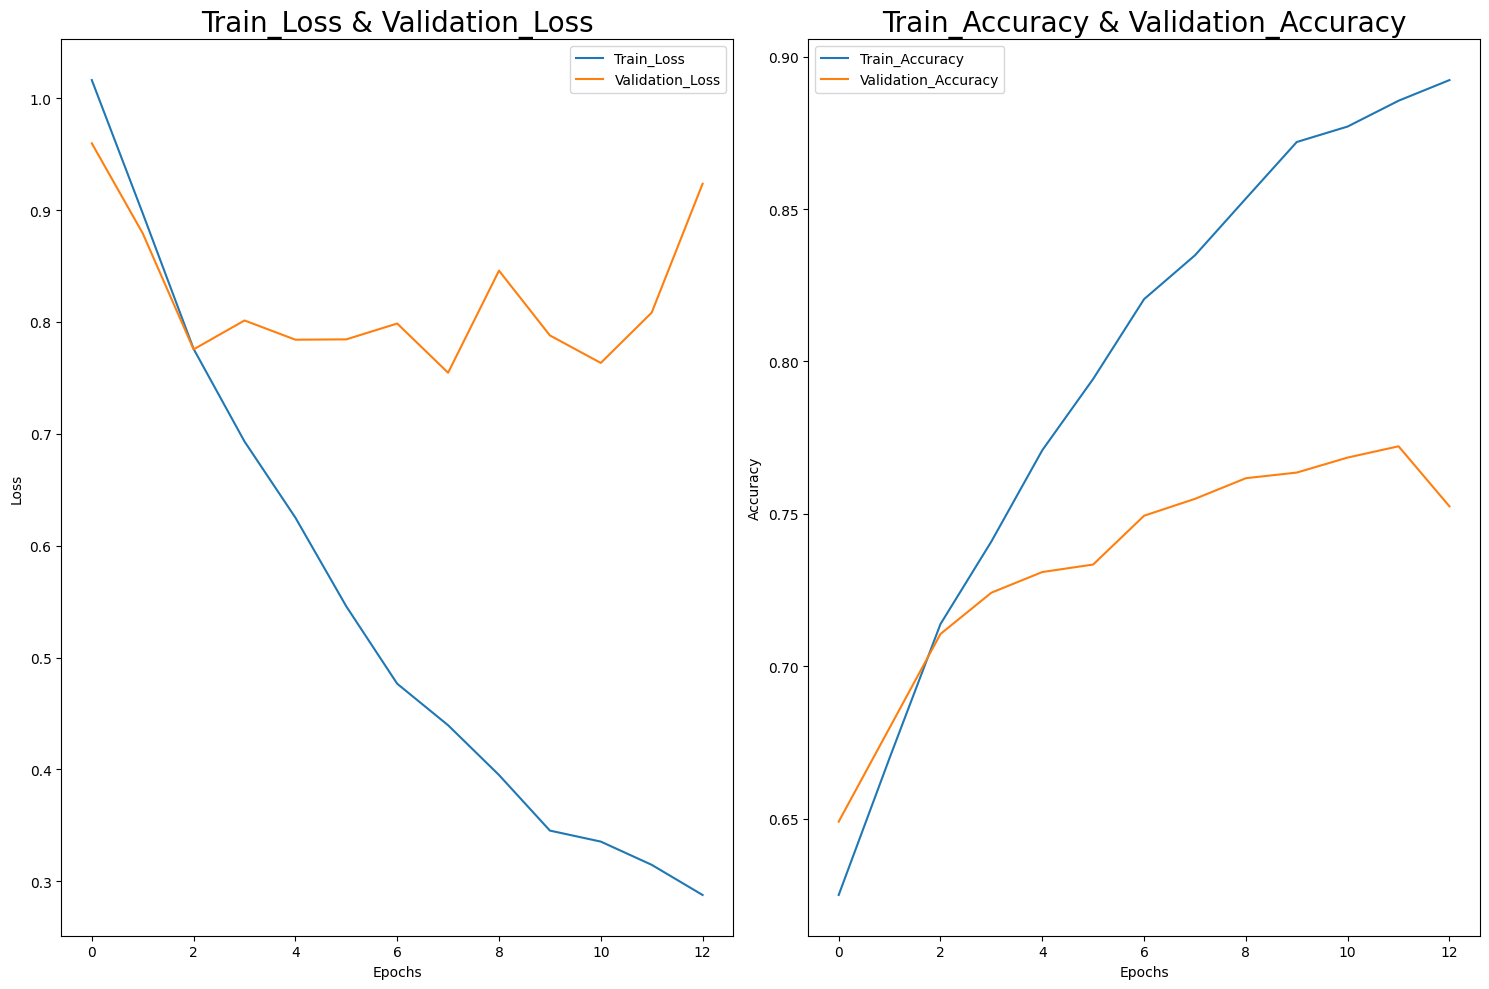

In [30]:
import matplotlib.pyplot as plt

# Show what columns are available
print("Available columns:", hist.columns)

plt.figure(figsize=(15, 10))

# Plot Loss if available
plt.subplot(1, 2, 1)
if 'loss' in hist.columns:
    plt.plot(hist['loss'], label='Train_Loss')
if 'val_loss' in hist.columns:
    plt.plot(hist['val_loss'], label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy if available
plt.subplot(1, 2, 2)
if 'accuracy' in hist.columns:
    plt.plot(hist['accuracy'], label='Train_Accuracy')
if 'val_accuracy' in hist.columns:
    plt.plot(hist['val_accuracy'], label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy', fontsize=20)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [31]:
# Evaluate the model on the test dataset using the test generator, getting the loss and accuracy
test_loss, acc = model.evaluate(test_generator)

print('Test Loss: ', test_loss)
print('Test Accuracy: ', acc)

d:\college\Blood_group\.venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


51/51 ━━━━━━━━━━━━━━━━━━━━ 45s 856ms/step - accuracy: 0.7579 - loss: 0.7068
Test Loss:  0.7280101180076599
Test Accuracy:  0.7643076777458191


In [32]:
y_test =test_generator.classes
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions,axis=1)
y_test = np.ravel(y_test)
y_pred = np.ravel(y_pred)
results = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})
results

51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 606ms/step


,Actual,Prediction
0,1,6
1,3,3
2,1,1
3,3,4
4,6,4
...,...,...
1620,1,1
1621,1,1
1622,5,4
1623,5,4


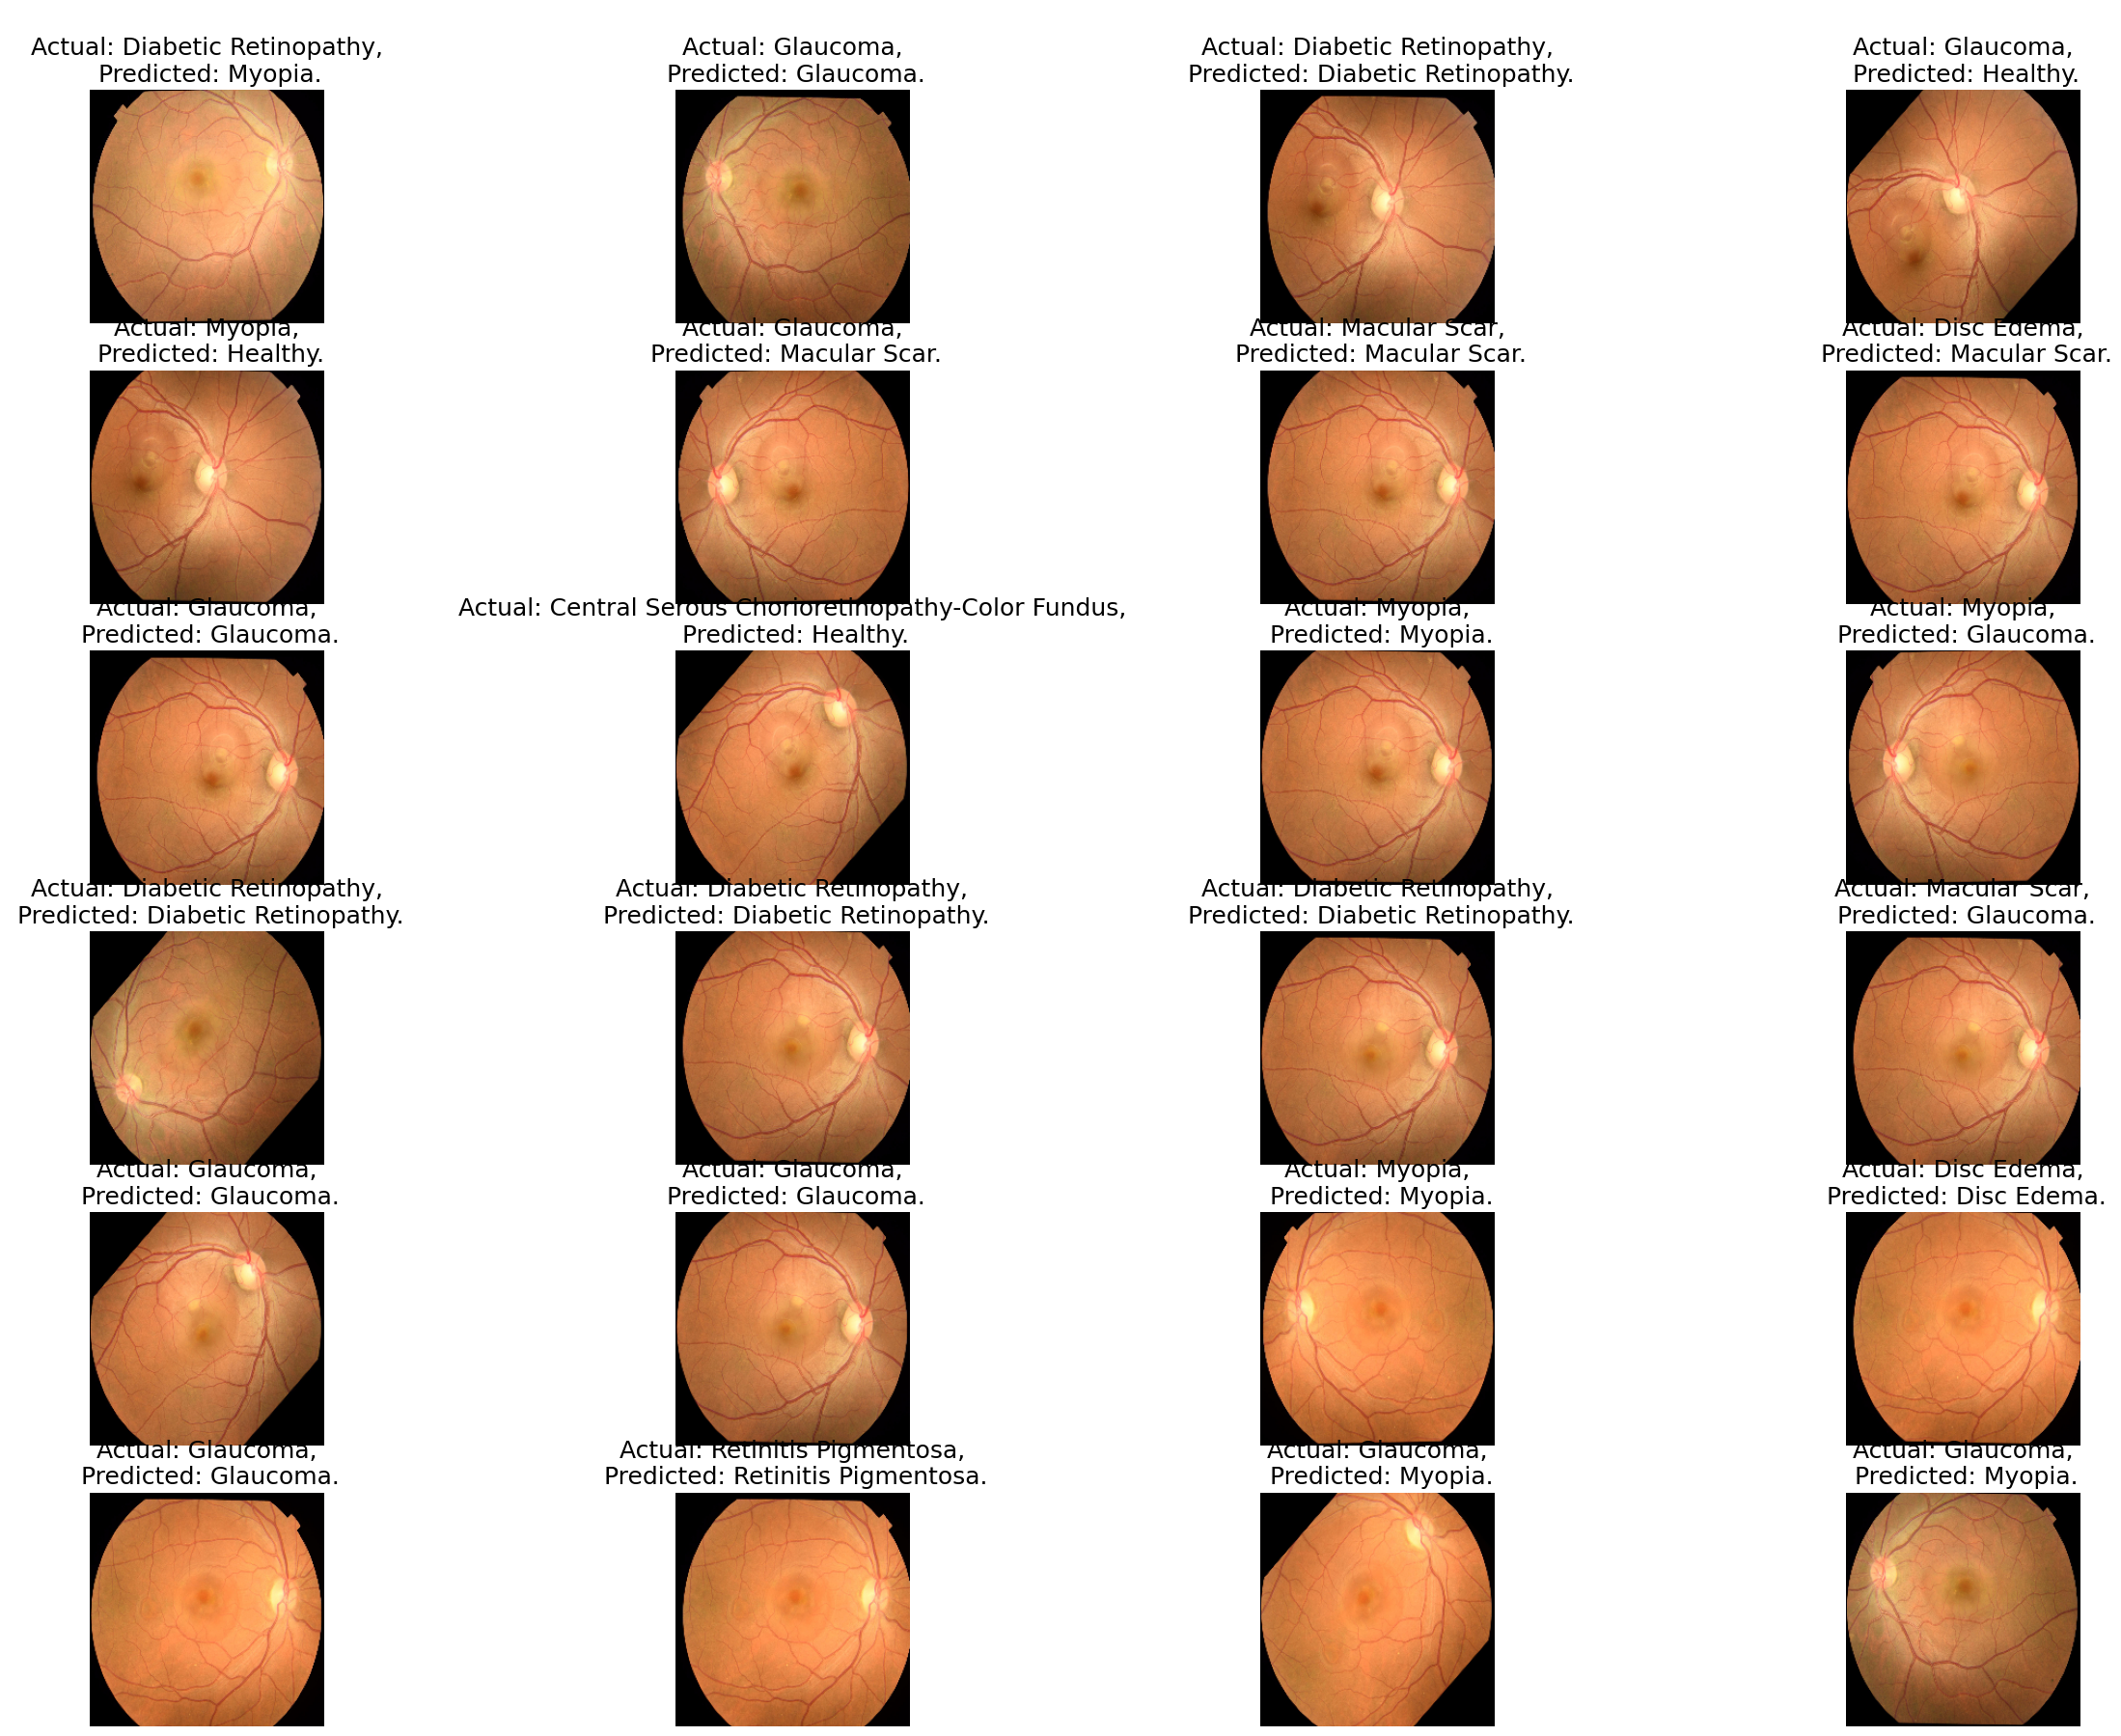

In [33]:
plt.figure(figsize=(30,90))
batch = next(test_generator)
images= batch[0]
for n in range(24):
    plt.subplot(24,4,n+1)
    img = cv2.imread(df.image[n])
    # Resize the image to 224x224 pixels (standard input size for many models)
    img = cv2.resize(img, (224, 224))
    # Convert the image from BGR (OpenCV format) to RGB (for correct display with matplotlib)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"\n Actual: {class_num[y_test[n]]}, \n Predicted: {class_num[y_pred[n]]}.",fontsize=18)

Classification Report : 
                                                 precision    recall  f1-score   support

Central Serous Chorioretinopathy-Color Fundus       0.78      0.52      0.62        60
                         Diabetic Retinopathy       0.92      0.88      0.90       345
                                   Disc Edema       0.79      0.82      0.81        76
                                     Glaucoma       0.66      0.60      0.63       288
                                      Healthy       0.67      0.81      0.73       268
                                 Macular Scar       0.66      0.58      0.62       194
                                       Myopia       0.75      0.85      0.80       225
                                    Pterygium       1.00      1.00      1.00        10
                           Retinal Detachment       0.96      0.91      0.93        75
                         Retinitis Pigmentosa       0.86      0.86      0.86        84

              

<Axes: >

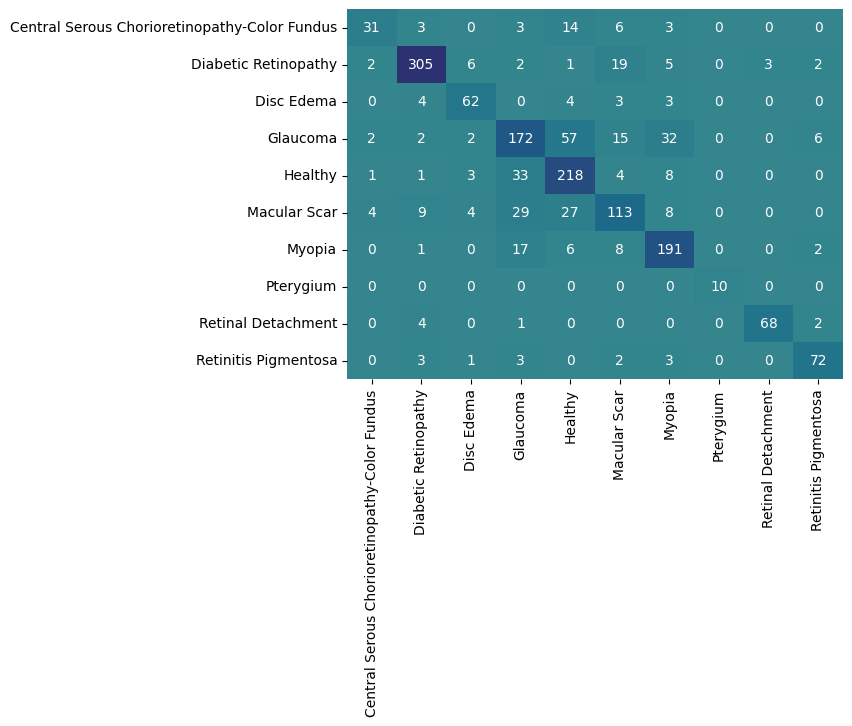

In [34]:
from sklearn.metrics import confusion_matrix, classification_report

CM = confusion_matrix(y_test, y_pred)

CM = sns.heatmap(confusion_matrix(y_test, y_pred), fmt='g', center=True, cbar=False, annot=True,
                 cmap='crest',
            xticklabels=class_num, yticklabels=class_num)



ClassificationReport = classification_report(y_test, y_pred, target_names=class_num)

print('Classification Report : \n ', ClassificationReport)

CM